In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from google.colab import files

#uploaded = files.upload()   #upload file in colab environment run only once to upload file
# Load dataset
df = pd.read_csv('q3_retail_promotions.csv')

#Task 1: Data feature engoneering
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract year, month, dayofweek
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek  # Monday=0

# Create is_month_end feature
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

# Display sample
print(df.head())

  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  year  month  \
0           1            0                    5         224  2022      1   
1           1            1                    1         348  2022      1   
2           1            0                    6         249  2022      1   
3           1            0                    7         259  2022      1   
4           0            0                    3         277  2022      1   

   day_of_week  is_month_end  
0            5             0  
1            5             0  
2          

In [23]:
# Task 2: temporal train-test split
df = df.sort_values(by='transaction_date')

# Split index
split_index = int(len(df) * 0.8)

# Train (first 80%), Test (last 20%)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (960, 13)
Test size: (240, 13)


In [24]:
#Random split do not take dates into consideration.
# In real life, we predict future using past data, so time order must be preserved.

In [25]:
#task3: preprocessing pipeline
target = 'items_sold'

# Features
X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

# Categorical & Numerical columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target column if present in numerical columns
if target in numerical_cols:
    numerical_cols.remove(target)

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)



In [26]:
#task4: model training and evaluation
#Linear regression pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

#prediction
y_pred_lr = lr_pipeline.predict(X_test)

#Random forest pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_pipeline.predict(X_test)


# Metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Linear Regression RMSE: 27.11258949801818
Linear Regression MAE: 21.011454141126485
Random Forest RMSE: 30.88270138152715
Random Forest MAE: 24.41792098214286


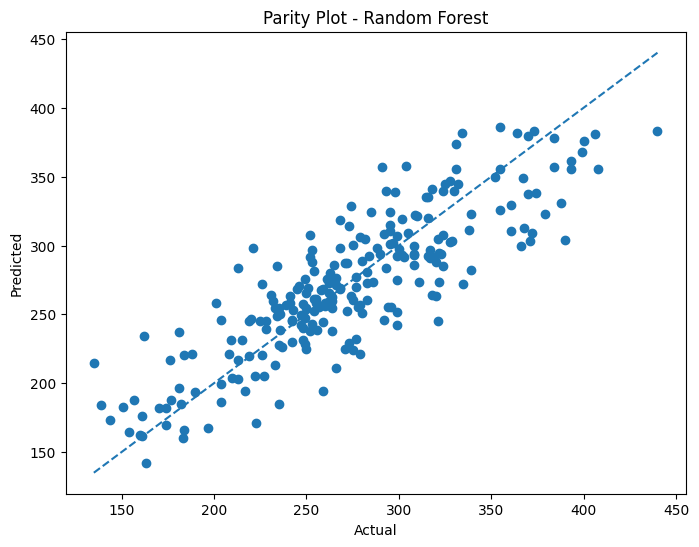

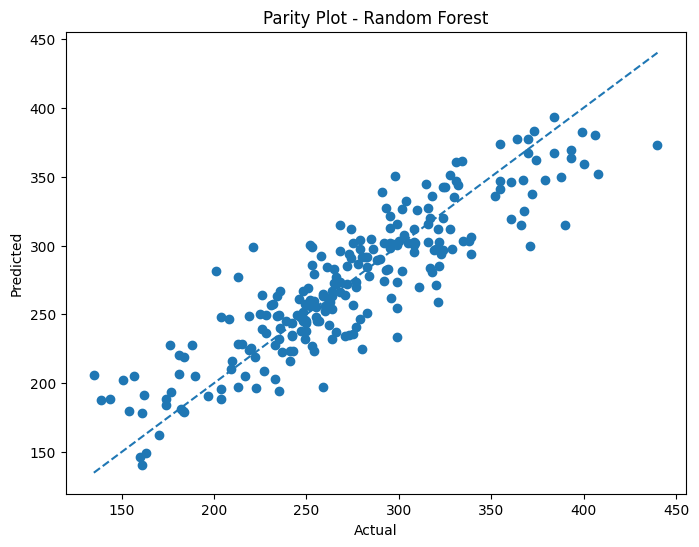

In [27]:
#parity plot - Random Forest
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Parity Plot - Random Forest")

# Diagonal line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.show()

#parity plot - Liinear regression
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Parity Plot - Random Forest")

# Diagonal line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.show()

In [28]:
# Get feature names after preprocessing
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)

all_features = list(encoded_cat_features) + numerical_cols

# Extract feature importance
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create dataframe
feat_imp_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Top 5 features
print(feat_imp_df.head(5))

                feature  importance
13          is_festival    0.173809
10     store_size_small    0.167119
12           is_weekend    0.128554
7   location_type_urban    0.109729
11             store_id    0.089050
